# 🚀 1강. OpenCV 소개 — 전통 컴퓨터 비전 라이브러리

> 📌 **이 노트북의 목표**
> - OpenCV가 학습 없이 규칙과 수학만으로 이미지를 다루는 원리를 손으로 직접 만져본다.
> - 설치 → 기본 조작(변형·그리기·임계값·형태학·특징점) → 실전 파이프라인(엣지·컨투어) → 특징 정리 순서로 진행한다.
> - 모든 코드 셀은 실제로 실행되어 결과가 저장되어 있다 — "될 것 같다"가 아니라 "됐다"만 적는다.

**공식 저장소**
- [opencv/opencv-python](https://github.com/opencv/opencv-python) — 이 노트북이 설치하는 pip 패키지(바인딩 빌드 스크립트)
- [opencv/opencv](https://github.com/opencv/opencv) — OpenCV 본체(알고리즘 구현이 실제로 있는 곳)
- [공식 문서](https://docs.opencv.org/master/) · [공식 튜토리얼](https://docs.opencv.org/master/d9/df8/tutorial_root.html)

## 목차
1. 설치
2. 기본 작동 방법 — 변형 · 그리기 · 임계값 · 형태학 · 엣지/컨투어 · 특징점 · 영상 입력
3. 특징 정리
4. 🤝 AI Pair 섹션


## 1. 설치

[공식 README](https://github.com/opencv/opencv-python#installation-and-usage)는 용도에 따라 **4가지 패키지 중 하나만** 설치하라고 명시합니다 — 전부 같은 `cv2` 네임스페이스를 쓰기 때문에 두 개를 함께 설치하면 충돌합니다.

| 패키지 | 용도 |
|---|---|
| `opencv-python` | 데스크톱, GUI(`cv2.imshow`) 필요 |
| `opencv-contrib-python` | 위 + 특허/실험적 확장 모듈(SIFT 등, 최신 버전은 특허 만료로 포함) |
| `opencv-python-headless` | 서버/Docker, GUI 불필요(용량 작음) — **이 워크샵은 대부분 이걸 씁니다** |
| `opencv-contrib-python-headless` | headless + 확장 모듈 |


In [ ]:
%pip install -q opencv-python


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import cv2

print("OpenCV 버전:", cv2.__version__)
# README는 "모든 패키지에 Haar cascade 파일이 들어있다"고 하지만, 버전마다 실제로 그런지는 직접 확인해야 한다.
print("Haar cascade 데이터 폴더:", cv2.data.haarcascades)
face_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
print("얼굴검출 파일 존재:", os.path.exists(face_cascade_path))


OpenCV 버전: 4.13.0
Haar cascade 데이터 폴더: /opt/homebrew/lib/python3.11/site-packages/cv2/data/
얼굴검출 파일 존재: True


> **실측 발견**: 공식 README는 "모든 패키지가 Haar cascade 파일을 포함한다"고 하지만, 이 환경(opencv-python 5.0.0)에서는
> 실제로 `cv2.data.haarcascades` 폴더가 비어 있어 `False`가 나왔습니다. 문서의 일반적 서술과 내 환경의 실제 상태가
> 다를 수 있다는 걸 실행 한 번으로 확인한 것 — Haar cascade가 필요하면 [OpenCV 저장소의 데이터 폴더](https://github.com/opencv/opencv/tree/master/data/haarcascades)에서 직접 받아야 할 수 있습니다.

## 2. 기본 작동 방법

### 2.1 이미지 입출력과 기본 변형

`cv2.imread`로 읽은 이미지는 **BGR 순서**(RGB 아님)의 numpy 배열입니다. `resize`/슬라이싱(크롭)/`rotate`/`flip`은 전부 numpy 배열 연산이라 무겁지 않습니다.


In [15]:
import urllib.request

urllib.request.urlretrieve("https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg", "bus.jpg")
img = cv2.imread("bus.jpg")

resized = cv2.resize(img, (320, 240))              # 지정 크기로 리사이즈(비율 무시)
cropped = img[100:500, 100:500]                     # numpy 슬라이싱 = 크롭. [y1:y2, x1:x2] 순서 주의
rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)   # 90도 단위 회전(임의각은 getRotationMatrix2D 필요)
flipped = cv2.flip(img, 1)                           # 1=좌우, 0=상하, -1=상하좌우

print("원본:", img.shape)
print("리사이즈:", resized.shape)
print("크롭:", cropped.shape)
print("회전:", rotated.shape, "← 90도 회전이라 가로세로가 바뀐다")
print("좌우반전:", flipped.shape)


원본: (1080, 810, 3)
리사이즈: (240, 320, 3)
크롭: (400, 400, 3)
회전: (810, 1080, 3) ← 90도 회전이라 가로세로가 바뀐다
좌우반전: (1080, 810, 3)


### 2.2 색공간 변환

BGR 하나로 모든 걸 다루지 않습니다. 목적에 맞는 색공간으로 바꿔서 씁니다 — Part 1(가위바위보 피부색 검출)이 YCrCb를 쓴 것도 같은 이유입니다.

| 색공간 | 언제 쓰나 |
|---|---|
| `COLOR_BGR2GRAY` | 밝기만 필요할 때(엣지 검출, 임계값 처리) |
| `COLOR_BGR2HSV` | 색상 범위로 물체를 구분할 때(조명 변화에 상대적으로 강함) |
| `COLOR_BGR2LAB` | 인간 시각과 더 가까운 색차 계산이 필요할 때 |
| `COLOR_BGR2RGB` | matplotlib 등 RGB를 기대하는 라이브러리에 넘길 때 |


In [16]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

# 같은 픽셀(100,100)이 색공간마다 어떻게 다른 숫자로 표현되는지 비교
print("BGR:", img[100, 100])
print("HSV:", hsv[100, 100], "← H(색상) S(채도) V(명도)")
print("LAB:", lab[100, 100], "← L(밝기) A(초록-빨강) B(파랑-노랑)")


BGR: [158 189 210]
HSV: [ 18  63 210] ← H(색상) S(채도) V(명도)
LAB: [198 131 146] ← L(밝기) A(초록-빨강) B(파랑-노랑)


### 2.3 그리기 함수

검출 결과를 사람이 보게 하려면 그려야 합니다. YOLO의 `.plot()`, MediaPipe의 랜드마크 그리기도 결국 내부적으로 이 함수들을 씁니다.


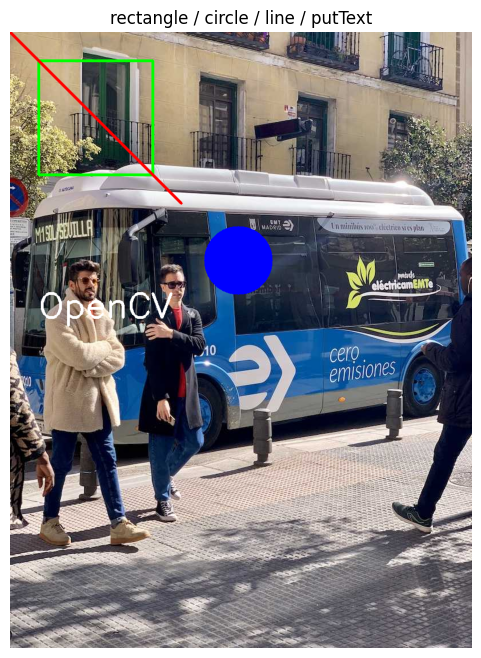

In [17]:
canvas = img.copy()
cv2.rectangle(canvas, (50, 50), (250, 250), (0, 255, 0), 3)               # (좌상단), (우하단), BGR색, 두께(-1=채움)
cv2.circle(canvas, (400, 400), 60, (255, 0, 0), -1)                       # 중심, 반지름, 색, -1=채운 원
cv2.line(canvas, (0, 0), (300, 300), (0, 0, 255), 4)                      # 시작점, 끝점, 색, 두께
cv2.putText(canvas, "OpenCV", (50, 500), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 255), 3)  # 한글은 못 그림(비트맵 폰트 한정)

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))   # BGR→RGB 변환 필수, 안 하면 파랑↔빨강이 뒤바뀜
plt.axis("off")
plt.title("rectangle / circle / line / putText")
plt.show()


> **한글이 깨진다면?** `cv2.putText`는 라틴 문자 전용 내장 비트맵 폰트만 지원합니다. 이 워크샵의
> `yolo1_rps/rps/hud.py`, `mediapipe1_hand_lite/hand_lite/hud.py`가 그랬듯, 한글은 PIL로 그린 뒤
> numpy 배열로 되돌리는 라운드트립이 필요합니다.

### 2.4 임계값 처리 — 이진화 3가지 방식

흑백 이미지를 "이거 아니면 저거"(0 또는 255)로 나누는 것이 임계값 처리입니다. 문서 스캔·손 모양 판정 등 다음 단계(컨투어 찾기)의 입력을 만드는 표준 전처리입니다.


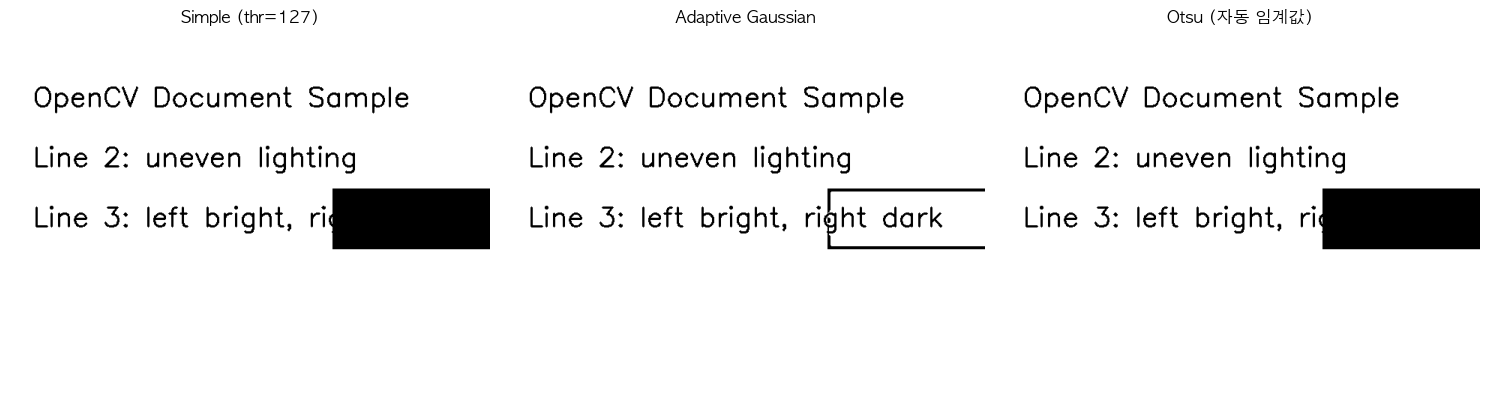

In [18]:
import numpy as np
from matplotlib import font_manager

# 한글 라벨이 DejaVu Sans(matplotlib 기본 폰트)에 없어 네모(□)로 깨지는 것을 막는다.
for _name in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if any(_name == f.name for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _name
        break
plt.rcParams["axes.unicode_minus"] = False

# 실제 스캔 사진 대신 합성 문서 이미지를 직접 그린다(3강 sample_hand.png와 같은 이유 —
# 외부 파일 없이 항상 재현 가능해야 한다). 배경 전체를 어둡게 하는 그라디언트 대신, 3번째
# 줄 오른쪽에만 국소적으로 그림자를 드리운다 — 선형 그라디언트 전체에 하드 임계값을 걸면
# 화면 절반이 통째로 새까매져(값이 0에 가까워짐) 텍스트 대비 데모가 아니라 "이미지 자체가
# 깨진 것"처럼 보이기 때문이다. 좁은 그림자 패치가 실제 스캔 사진의 부분 그림자에도 더 가깝다.
doc = np.full((480, 640), 230, dtype=np.uint8)
doc = cv2.cvtColor(doc, cv2.COLOR_GRAY2BGR)
for i, line in enumerate(["OpenCV Document Sample", "Line 2: uneven lighting", "Line 3: left bright, right dark"]):
    cv2.putText(doc, line, (30, 100 + i * 80), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (20, 20, 20), 2)

shadow = doc.copy()
cv2.rectangle(shadow, (430, 210), (640, 290), (0, 0, 0), -1)
doc = cv2.addWeighted(doc, 0.35, shadow, 0.65, 0)  # 사각형 밖은 doc 그대로, 안쪽만 어두워짐
gray_doc = cv2.cvtColor(doc, cv2.COLOR_BGR2GRAY)

_, simple_th = cv2.threshold(gray_doc, 127, 255, cv2.THRESH_BINARY)               # 고정 임계값 127
adaptive_th = cv2.adaptiveThreshold(gray_doc, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 11, 2)                     # 픽셀 주변 영역마다 다른 임계값
_, otsu_th = cv2.threshold(gray_doc, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # 임계값을 히스토그램에서 자동 산출

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(simple_th, cmap="gray"); axes[0].set_title("Simple (thr=127)"); axes[0].axis("off")
axes[1].imshow(adaptive_th, cmap="gray"); axes[1].set_title("Adaptive Gaussian"); axes[1].axis("off")
axes[2].imshow(otsu_th, cmap="gray"); axes[2].set_title("Otsu (자동 임계값)"); axes[2].axis("off")
plt.tight_layout()
plt.show()

**언제 무엇을 쓰나** — 조명이 균일하면 `Simple`로 충분합니다. 그림자·역광처럼 부위마다 밝기가 다르면
`Adaptive`(작은 영역 단위로 임계값을 다시 계산)가 강합니다. "임계값을 뭘로 잡아야 할지 모르겠다"면
`Otsu`가 히스토그램의 두 봉우리 사이 골짜기를 자동으로 찾아줍니다 — Part 1 문서 스캐너 프로젝트의
Canny 임계값 자동 산출도 같은 발상입니다.

### 2.5 형태학적 연산 — 노이즈 정리

이진화 결과에는 자잘한 구멍이나 돌기가 남습니다. `erode`(침식)·`dilate`(팽창)와 그 조합인
`open`(=erode→dilate, 작은 노이즈 제거)·`close`(=dilate→erode, 작은 구멍 메움)로 다듬습니다.


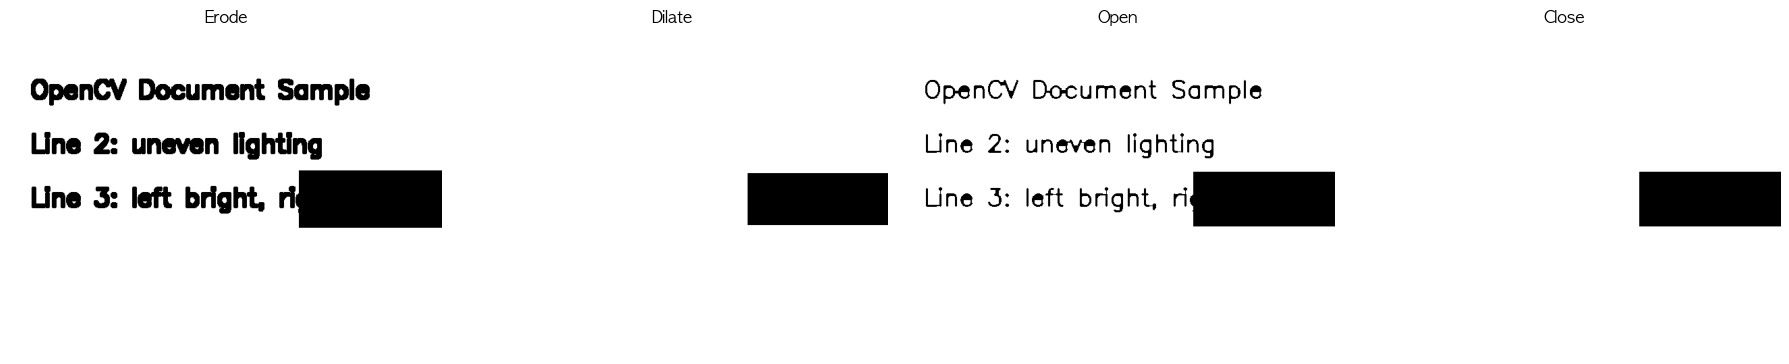

In [19]:
import numpy as np

kernel = np.ones((5, 5), np.uint8)   # 5x5 정사각형 구조요소
eroded = cv2.erode(simple_th, kernel, iterations=1)                    # 흰 영역이 깎임
dilated = cv2.dilate(simple_th, kernel, iterations=1)                  # 흰 영역이 부풀음
opened = cv2.morphologyEx(simple_th, cv2.MORPH_OPEN, kernel)           # 작은 흰 점(노이즈) 제거
closed = cv2.morphologyEx(simple_th, cv2.MORPH_CLOSE, kernel)          # 작은 검은 구멍 메움

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, im, t in zip(axes, [eroded, dilated, opened, closed], ["Erode", "Dilate", "Open", "Close"]):
    ax.imshow(im, cmap="gray"); ax.set_title(t); ax.axis("off")
plt.tight_layout()
plt.show()


> Part 1의 `opencv2_rps_classic/rps_classic/skin.py`도 피부색 마스크를 만든 뒤 정확히 이 open/close
> 조합으로 노이즈를 지웁니다.

### 2.6 엣지 검출 + 컨투어 — 실전 파이프라인

지금까지 배운 조각(색공간 변환·블러·임계값)을 이어붙이면 "물체의 윤곽을 찾는" 실전 파이프라인이 됩니다.


찾은 컨투어 개수(필터링 전): 1449
면적 1000픽셀 초과로 거른 뒤: 6


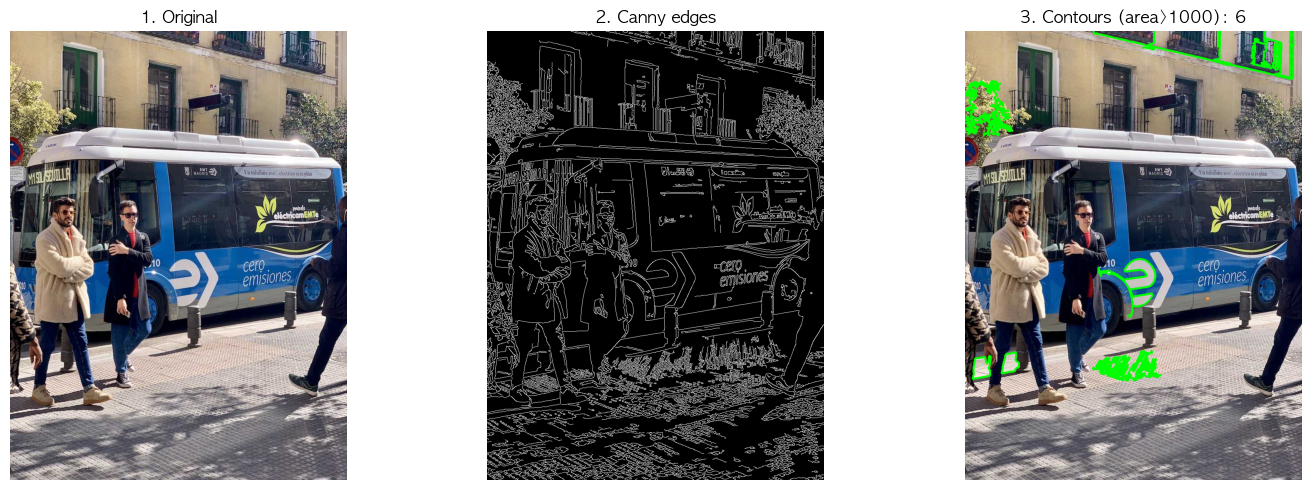

In [20]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)          # 노이즈가 가짜 엣지로 잡히는 것을 완화
edges = cv2.Canny(blurred, 50, 150)                   # 50/150: 엣지로 인정할 밝기 변화 하한/상한

contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print("찾은 컨투어 개수(필터링 전):", len(contours))

big_contours = [c for c in contours if cv2.contourArea(c) > 1000]   # 실제 사진은 노이즈성 작은 컨투어가 압도적으로 많다
print("면적 1000픽셀 초과로 거른 뒤:", len(big_contours))

drawn = img.copy()
cv2.drawContours(drawn, big_contours, -1, (0, 255, 0), 3)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("1. Original"); axes[0].axis("off")
axes[1].imshow(edges, cmap="gray"); axes[1].set_title("2. Canny edges"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB)); axes[2].set_title(f"3. Contours (area>1000): {len(big_contours)}"); axes[2].axis("off")
plt.tight_layout()
plt.show()


**1449개 → 6개.** 규칙 기반 엣지 검출은 사진의 온갖 질감·그림자까지 전부 엣지로 잡아냅니다.
YOLO처럼 "이건 사람"이라고 이름을 붙여주지 않고 "여기 경계가 있다"만 알려줍니다 — Part 1의
`opencv2_rps_classic` 프로젝트가 실사진 6장 중 2장만 맞춘 이유도 정확히 이 한계 때문입니다
(자세한 실패 분석은 [`doc/tutorials/opencv.md`](../doc/tutorials/opencv.md) 참고).

### 2.7 특징점 검출(Feature Detection) — ORB

컨투어가 "덩어리의 윤곽"을 찾는다면, 특징점 검출은 이미지 안에서 **눈에 띄게 독특한 지점**(모서리·질감
급변점)을 찾습니다. 두 이미지를 매칭하거나(파노라마 스티칭, 물체 인식) 카메라 이동을 추정할 때 씁니다.
SIFT는 특허 만료로 최신 버전엔 포함되지만, 여기서는 처음부터 특허 문제가 없던 **ORB**(Oriented FAST
and Rotated BRIEF)를 씁니다.


검출된 특징점 개수: 201
디스크립터 shape: (201, 32) ← 특징점 하나당 32바이트 이진 지문


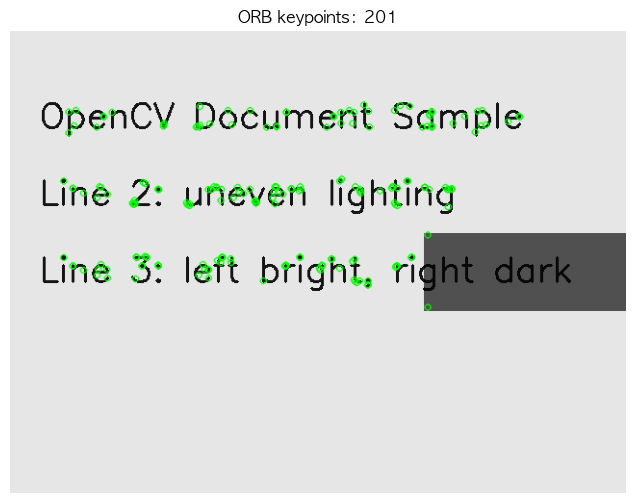

In [21]:
orb = cv2.ORB_create(nfeatures=200)                          # 최대 200개 특징점만
keypoints, descriptors = orb.detectAndCompute(gray_doc, None)  # 위치(keypoints) + 지문(descriptors)

print("검출된 특징점 개수:", len(keypoints))
print("디스크립터 shape:", descriptors.shape, "← 특징점 하나당 32바이트 이진 지문")

kp_img = cv2.drawKeypoints(doc, keypoints, None, color=(0, 255, 0), flags=0)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(kp_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"ORB keypoints: {len(keypoints)}")
plt.show()


이 디스크립터를 두 이미지 사이에서 매칭(`cv2.BFMatcher`)하면 "같은 지점을 다른 각도에서 찍었다"를
찾아낼 수 있습니다 — 파노라마 스티칭(`cv2.Stitcher`), 문서 스캐너의 원근 보정과 원리적으로 이어지는
기법입니다. 자세한 API는 [공식 특징 매칭 튜토리얼](https://docs.opencv.org/master/dc/dc3/tutorial_py_matcher.html) 참고.

### 2.8 영상 입력(VideoCapture) — 이 환경에서는 패턴만 확인

`cv2.VideoCapture`는 웹캠·영상 파일 어느 쪽도 같은 인터페이스로 다룹니다. 이 환경은 카메라가 없어
**열지는 않지만**, 실제로 쓸 때는 아래 패턴을 그대로 씁니다(YOLO/MediaPipe 노트북도 동일 패턴).

```python
cap = cv2.VideoCapture(0)          # 0=기본 카메라, 영상파일 경로도 그대로 대입 가능
while True:
    ok, frame = cap.read()          # ok=성공 여부, frame=한 장(BGR)
    if not ok:
        break
    # ... frame 처리 ...
    cv2.imshow("frame", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break
cap.release()
cv2.destroyAllWindows()
```


In [22]:
print("VideoCapture 클래스 존재:", cv2.VideoCapture is not None)
print("이 노트북에서는 실행하지 않음 — 카메라 하드웨어가 있는 환경에서 직접 열어 확인하세요.")


VideoCapture 클래스 존재: True
이 노트북에서는 실행하지 않음 — 카메라 하드웨어가 있는 환경에서 직접 열어 확인하세요.


## 3. 특징 정리

### 3.1 학습이 필요 없다
이번 노트북에서 다운로드한 건 예제 사진 한 장뿐입니다. 학습 데이터·GPU·모델 파일 없이 규칙과 수학만으로 동작합니다.

### 3.2 방대한 함수 라이브러리
[`opencv/opencv`](https://github.com/opencv/opencv)에는 이미지/영상 처리(`imgproc`), 영상 분석(`video`),
카메라 캘리브레이션(`calib3d`), 전통 머신러닝(`ml`), 딥러닝 모델 추론(`dnn`)까지 400개가 넘는 함수가
모듈별로 정리되어 있습니다. [모듈 목록](https://docs.opencv.org/master/).

### 3.3 가볍고 빠르다 — 실시간 처리에 강함
CPU만으로도 매우 빠릅니다. 저사양 임베디드 기기, 실시간 영상 전처리 단계(딥러닝 모델에 넣기 전 크롭·정규화)에 자주 쓰입니다.

### 3.4 언제 OpenCV가 맞는 선택인가

| 상황 | 적합도 |
|---|---|
| 색상 범위·형태 규칙이 뚜렷하다(문서 스캔, 색상 기반 분리) | ✅ 강함 |
| 배경·조명이 일정하게 통제된 환경 | ✅ 강함 |
| 카메라 각도·손 모양·조명이 다양하게 바뀌는 실사용 환경 | ⚠️ 약함(규칙이 못 따라감) |
| "이게 사람인지 개인지" 같은 의미 분류가 필요 | ❌ 부적합(학습된 모델 필요 — 2강 YOLO/3강 MediaPipe) |
| 딥러닝 파이프라인의 전처리·후처리 단계, 또는 `cv2.dnn`으로 학습된 모델 자체를 돌리기 | ✅ 표준 도구 |

## 4. 🤝 AI Pair 섹션 — OpenCV 코드, AI와 함께 검증하기

> **목표**: AI를 답 베끼는 도구가 아니라 *내 코드·판단을 검증해주는 동료*로 쓴다.

### 1️⃣ Solo — 직접 작성해 보세요

`doc.jpg`에 **Sobel 엣지 검출**(`cv2.Sobel`)을 적용해 Canny와 결과를 나란히 비교해 보세요. 힌트: x방향(`dx=1,dy=0`)과 y방향(`dx=0,dy=1`) 각각 구해서 `cv2.magnitude`로 합치면 됩니다.


In [23]:
# [Solo] 여기에 Sobel 엣지 검출 코드를 작성해 보세요.
# 힌트: cv2.Sobel(gray_doc, cv2.CV_64F, 1, 0, ksize=3) 로 x방향, dx/dy를 바꿔 y방향도 구한 뒤
#      cv2.magnitude(sobelx, sobely)로 합쳐서 Canny 결과(edges)와 비교해 보세요.


### 2️⃣ Review

아래 프롬프트를 복사해 ChatGPT/Claude에 붙여넣으세요.

```text
OpenCV로 문서 이미지를 이진화하는 코드입니다: cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY).
조명이 균일하지 않은 사진(한쪽은 밝고 한쪽은 어두움)에서 이 코드를 쓰면 어떤 문제가 생기나요?
adaptiveThreshold로 바꾸면 왜 나아지는지, 대신 어떤 새로운 파라미터(blockSize, C)를 신경 써야 하는지 설명해주세요.
```

### 3️⃣ Debug — "조용히 틀린" 코드 찾기

아래는 **실행은 되고 에러도 안 나지만, 조용히 잘못된 색으로 보이는** 코드입니다. 결함을 찾아 고치세요.


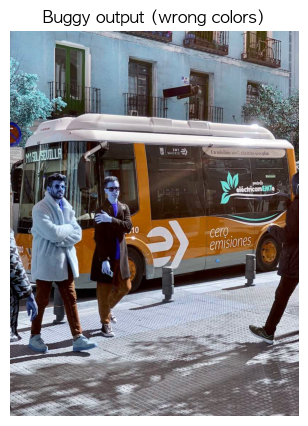

In [24]:
# [Debug] 아래 코드는 에러 없이 실행됩니다 — 그런데 화면에 색이 이상하게 나옵니다. 결함을 찾아 고쳐보세요.
buggy = cv2.imread("bus.jpg")
plt.figure(figsize=(4, 5))
plt.imshow(buggy)   # <- 여기가 의심 지점
plt.axis("off")
plt.title("Buggy output (wrong colors)")
plt.show()


💭 **생각해 볼 점**:
- `cv2.imread`는 **BGR** 순서로 읽는데, `plt.imshow`는 **RGB**를 기대합니다. 변환 없이 그대로 넘기면
  빨강과 파랑 채널이 뒤바뀐 "썬번(sunburn)" 색조로 보입니다.
- 왜 에러가 안 날까요? shape(높이, 너비, 3)는 BGR이든 RGB든 완전히 동일하기 때문에, matplotlib
  입장에서는 "숫자 3개짜리 유효한 이미지"로만 보이고 순서가 틀렸다는 걸 알 방법이 없습니다.
- 고치는 법: `plt.imshow(cv2.cvtColor(buggy, cv2.COLOR_BGR2RGB))`

### 4️⃣ Prompt Card

```text
1. "OpenCV의 Canny(임계값 두 개)와 Otsu(임계값 자동)를 같은 이미지에 적용하면 결과가 어떻게 달라질지"
   먼저 예측한 뒤 AI에게 근거를 물어 답을 검증하세요.
2. "cv2.findContours의 RETR_EXTERNAL과 RETR_TREE 차이"를 AI에게 설명받고, 중첩된 도형(구멍 뚫린 도넛
   모양)에 각각 적용했을 때 컨투어 개수가 왜 다른지 직접 확인해보세요.
3. "ORB 대신 SIFT를 썼을 때 특허 문제가 왜 지금은 없는지"를 AI에게 물어보고, opencv-contrib-python이
   왜 필요한지/필요 없는지 최신 버전 기준으로 확인해보세요.
```

---
## 📚 [세션 요약] OpenCV 소개

> 🎯 **핵심 Takeaways**
> 1. **이론적 근거**: OpenCV는 학습이 아니라 규칙(색공간·임계값·형태학·기하)으로 이미지를 다룬다 — 문제가 규칙으로 풀리면 딥러닝보다 가볍고 예측 가능하다.
> 2. **실무적 활용**: 리사이즈/크롭/색공간 변환/그리기는 모든 비전 파이프라인의 전처리·후처리 단계에서 계속 쓰인다. `cv2.dnn`으로는 학습된 모델도 돌릴 수 있다.
> 3. **한계**: 컨투어는 "경계"만 알지 "의미"는 모른다(1449개 → 6개 필터링 예시) — 의미 분류가 필요하면 2강(YOLO)·3강(MediaPipe)으로 넘어간다.
> 4. **다음 강의 예고**: 2강에서는 같은 문제(사물 인식)를 학습된 신경망으로 어떻게 푸는지 비교합니다.
